# Case 920 BESTEST validation

Native ISO is the formal ASHRAE 140 result. `modelica_solar` is a controlled-forcing comparative run and is not a formal result.

In [1]:
CASE="920"
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
ISO_MODE = "modelica_solar"  # "modelica_solar" or "native"
root = Path.cwd()
if not (root / "scripts").is_dir(): root = root.parent
sys.path.insert(0, str(root / "scripts"))
from bestest_reporting import annual_energy_table, completed_hour_label, markdown_table, selected_iso_mode
from case9xx_reporting import annual_tracks, comparison_table, peak_tracks, prescribed_changes, range_judgement
case = CASE
out = root / "results" / f"case{case}"
reference = root / "_ref" / "BESTEST_LBNL_all_cases_reference.md"
metrics = pd.read_csv(out / f"case{case}_metrics.csv")
solar = pd.read_csv(out / f"case{case}_solar_comparison.csv")
references = pd.concat([pd.DataFrame([{"case": r.Case, "metric": metric, "lower": float(r.Lower), "upper": float(r.Upper)} for _, r in markdown_table(reference, section).iterrows()]) for section, metric in (("Annual heating energy reference data", "annual_heating_energy"), ("Annual cooling energy reference data", "annual_cooling_energy"))], ignore_index=True)
_, ISO_LABEL = selected_iso_mode(ISO_MODE)

## 1. Case definition

Case 920 inherits Case 600 with these explicit BESTEST changes:

- window distribution: west 6 m2; east 6 m2; no south window

Weather: Denver TMY3; non-leap calendar; simulation/output timestep: 1 h.

In [2]:
display(prescribed_changes(case)); base=json.loads((root/'inputs'/'case900.json').read_text()); display(pd.DataFrame([{"Geometry":f"{base['geometry']['floor_area_m2']} m² floor; {base['geometry']['volume_m3']} m³ volume","Construction":base['constructions']['mass_class'],"Weather":base['weather']['identifier'],"Timestep":"1 h"}])); display(pd.read_csv(root/'inputs'/'case900_adapter_mapping.csv')[['quantity','ashrae_value','ashrae_unit','modelica_parameter','iso_parameter','mapping_type']])

,case,prescribed_change
0,920,window distribution: west 6 m2; east 6 m2; no ...


,Geometry,Construction,Weather,Timestep
0,48.0 m² floor; 129.6 m³ volume,heavyweight,USA_CO_Denver.Intl.AP.725650_TMY3,1 h


,quantity,ashrae_value,ashrae_unit,modelica_parameter,iso_parameter,mapping_type
0,floor area,48,m2,zonHVAC.AFlo,Zone.floor_area,direct
1,room volume,129.6,m3,zonHVAC.VRoo,Zone.room_vol,direct
2,south window area,12,m2,zonHVAC.AWin[3],Zone.window_area,direct
3,wall/roof/floor U-values,0.53/0.33/0.038,W/m2K,zonHVAC.UWal/URoo/UFlo,Zone aggregate opaque UA,aggregated
4,window U-value and g-value,3.1/0.769,W/m2K/-,zonHVAC.UWin/gFac,Zone.u_windows/Window.glass_solar_transmittance,direct
5,thermal mass capacity,307750,J/m2K,buiMas.heaC,Zone.thermal_capacitance_per_floor_area,direct
6,effective mass area factor,2.43,m2/m2,buiMas.facMas,Zone.effective_mass_area_per_floor_area,direct
7,infiltration,0.414,1/h,zonHVAC.airRat,Zone.h_ve_adj,derived
8,internal sensible gain,200,W,intGai.k,Zone.solve_energy,direct
9,setpoints,20/27,degC,TSetHea/TSetCoo,Zone.t_set_heating/t_set_cooling,direct


## 2. Annual heating and cooling

Three computed tracks, MWh.

In [3]:
display(annual_tracks(metrics))

,Run,Heating MWh,Cooling MWh
0,Native ISO,3.539694,2.109828
1,ISO + Modelica solar,3.635015,2.688719
2,Modelica native,3.649996,2.684319


## 3. Annual energy validation outcome

Formal annual-energy judgement for native ISO only.

In [4]:
display(range_judgement(metrics,references,case))

,Metric,Native ISO MWh,ASHRAE lower MWh,ASHRAE upper MWh,Distance to violated bound MWh,Distance %,Formal status
0,Heating,3.539694,2.55,4.20,0.000000,0.000000,PASS
1,Cooling,2.109828,2.43,3.08,-0.320172,-13.175792,FAIL


## 4. Annual heating figure

Annual heating energy with published ASHRAE limits.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,920,2.55,4.2,3.5,2.956,3.259,3.337,3.3,3.607,3.649996,3.635015,PASS — diagnostic


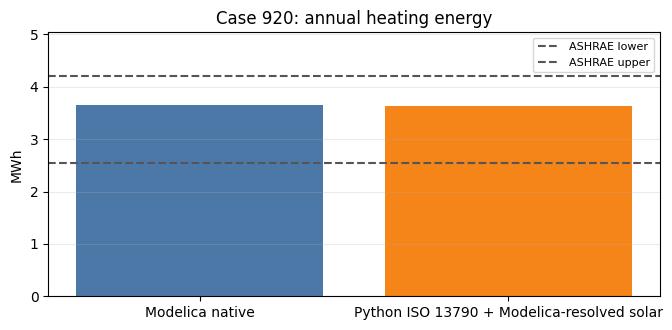

In [5]:
table=annual_energy_table(metrics, reference, case, "annual_heating_energy", ISO_MODE)
display(table)
row=table.iloc[0]; labels=["Modelica native", ISO_LABEL]; values=[row["Modelica native"],row[ISO_LABEL]]
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(labels,values,color=["#4C78A8","#F58518"])
ax.axhline(row["ASHRAE lower"],color="#555",linestyle="--",label="ASHRAE lower"); ax.axhline(row["ASHRAE upper"],color="#555",linestyle="--",label="ASHRAE upper")
ax.set(title=f"Case {case}: annual heating energy",ylabel="MWh",ylim=(0,max(values+[row["ASHRAE upper"]])*1.2)); ax.legend(fontsize=8); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 5. Annual cooling figure

Annual cooling energy with published ASHRAE limits.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,920,2.43,3.08,3.128,2.789,2.706,2.731,2.814,2.549,2.684319,2.688719,PASS — diagnostic


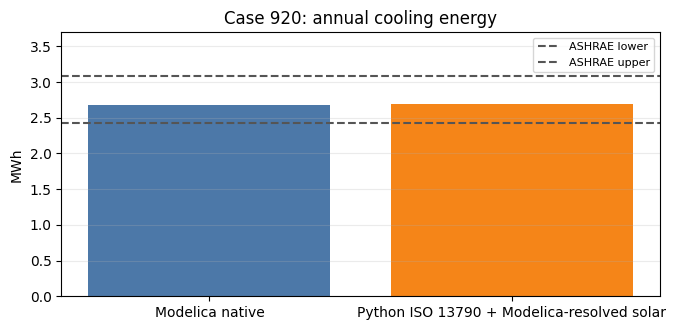

In [6]:
table=annual_energy_table(metrics, reference, case, "annual_cooling_energy", ISO_MODE)
display(table)
row=table.iloc[0]; labels=["Modelica native", ISO_LABEL]; values=[row["Modelica native"],row[ISO_LABEL]]
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(labels,values,color=["#4C78A8","#F58518"])
ax.axhline(row["ASHRAE lower"],color="#555",linestyle="--",label="ASHRAE lower"); ax.axhline(row["ASHRAE upper"],color="#555",linestyle="--",label="ASHRAE upper")
ax.set(title=f"Case {case}: annual cooling energy",ylabel="MWh",ylim=(0,max(values+[row["ASHRAE upper"]])*1.2)); ax.legend(fontsize=8); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 6. Peak heating and cooling

Computed peak loads and completed-hour occurrence times.

In [7]:
display(peak_tracks(metrics,completed_hour_label))

,Track,Peak heating kW,Peak heating time,Peak cooling kW,Peak cooling time
0,Modelica native,2.727867,09-Feb:06,2.797514,26-Jun:18
1,Native ISO,2.726149,09-Feb:06,2.522977,26-Jun:17
2,ISO + Modelica solar,2.731935,09-Feb:06,2.770142,26-Jun:18


## 7. Peak-load comparison figures

Computed peak loads, kW.

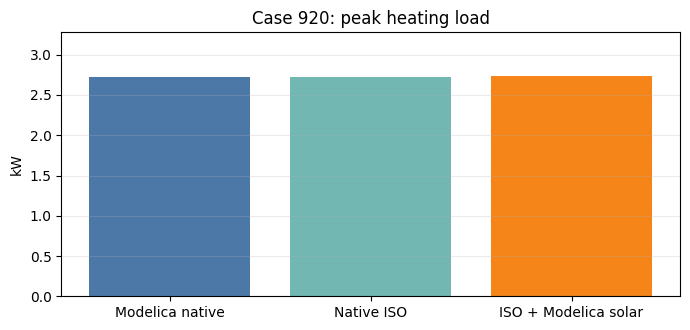

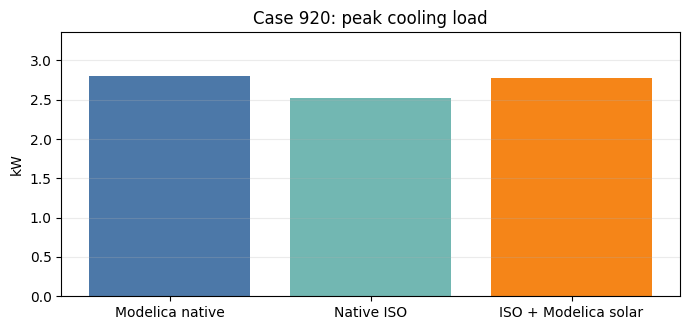

In [8]:
peaks=peak_tracks(metrics, completed_hour_label)
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(peaks["Track"],peaks["Peak heating kW"],color=["#4C78A8","#72B7B2","#F58518"])
ax.set(title=f"Case {case}: peak heating load",ylabel="kW",ylim=(0,peaks["Peak heating kW"].max()*1.2 if peaks["Peak heating kW"].max() else 1)); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()
peaks=peak_tracks(metrics, completed_hour_label)
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(peaks["Track"],peaks["Peak cooling kW"],color=["#4C78A8","#72B7B2","#F58518"])
ax.set(title=f"Case {case}: peak cooling load",ylabel="kW",ylim=(0,peaks["Peak cooling kW"].max()*1.2 if peaks["Peak cooling kW"].max() else 1)); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 8. Daily load profile

The LBNL presentation requires daily load profiles only for Cases 600 and 900; none is added for this 6XX case.

## 9. Solar forcing

Annual zone-solar totals, MWh.

In [9]:
solar_report=solar.set_index('quantity').T; solar_report['Absolute difference MWh']=(solar_report['native_rclib_zone_solar_MWh']-solar_report['modelica_resolved_zone_solar_MWh']).abs(); solar_report['Relative difference %']=(solar_report['native_modelica_ratio']-1)*100; display(solar_report.reset_index(drop=True))

quantity,native_rclib_zone_solar_MWh,modelica_resolved_zone_solar_MWh,native_modelica_ratio,Absolute difference MWh,Relative difference %
0,8.62566,9.349927,0.922538,0.724267,-7.746227


## 10. Controlled-forcing agreement

ISO + Modelica solar minus Modelica native; diagnostic only.

In [10]:
display(comparison_table(metrics,"controlled_modelica"))

,Metric,Unit,Modelica,ISO + Modelica solar,Difference,Difference %
0,Annual heating,MWh,3.649996,3.635015,-0.014981,-0.410444
1,Annual cooling,MWh,2.684319,2.688719,0.004399,0.163882
2,Peak heating,kW,2.727867,2.731935,0.004068,0.149123
3,Peak cooling,kW,2.797514,2.770142,-0.027373,-0.978462


## 11. Native versus controlled-forcing effect

Effect of changing only solar forcing in ISO.

In [11]:
display(comparison_table(metrics,"solar_effect").query("Metric in ['Annual heating', 'Annual cooling']"))

,Metric,Unit,Native ISO,ISO + Modelica solar,Difference,Difference %
0,Annual heating,MWh,3.539694,3.635015,0.095321,2.692903
1,Annual cooling,MWh,2.109828,2.688719,0.578890,27.437794


## 12. Final case outcome

Concise formal-native and controlled-forcing record.

In [12]:
judgement=range_judgement(metrics,references,case); summary=annual_tracks(metrics).set_index('Run'); summary['Formal ASHRAE status']=['; '.join(judgement['Formal status']),'diagnostic','reference implementation']; display(summary.reset_index()); print('Native ISO formal annual status:','; '.join(judgement['Formal status'])); print('Controlled forcing remains a Modelica-comparative diagnostic; no new schema or timestamp mapping is introduced.')

,Run,Heating MWh,Cooling MWh,Formal ASHRAE status
0,Native ISO,3.539694,2.109828,PASS; FAIL
1,ISO + Modelica solar,3.635015,2.688719,diagnostic
2,Modelica native,3.649996,2.684319,reference implementation


Native ISO formal annual status: PASS; FAIL
Controlled forcing remains a Modelica-comparative diagnostic; no new schema or timestamp mapping is introduced.
